In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
df_xgb = pd.read_csv("data/MDM2_Breaker/processed/xgboost_benchmark_random_seed_results.csv")
df_gdta_early_stopping = pd.read_csv("data/MDM2_Breaker/processed/graphdta_sched_decay_early_stopping_benchmark_random_seed_results.csv")
df_gdta_no_early_stopping = pd.read_csv("data/MDM2_Breaker/processed/graphdta_benchmark_random_seed_results.csv")


In [32]:
df_gdta_no_early_stopping['r2'].iloc[40:45]

40    0.620109
41    0.601248
42    0.658322
43    0.650876
44    0.612753
Name: r2, dtype: float64

In [33]:
df_gdta_no_early_stopping.to_csv(os.path.join("data", "MDM2_Breaker", "processed", "graphdta_sched_decay_nostopp_benchmark_random_seed_results.csv"), index=False)


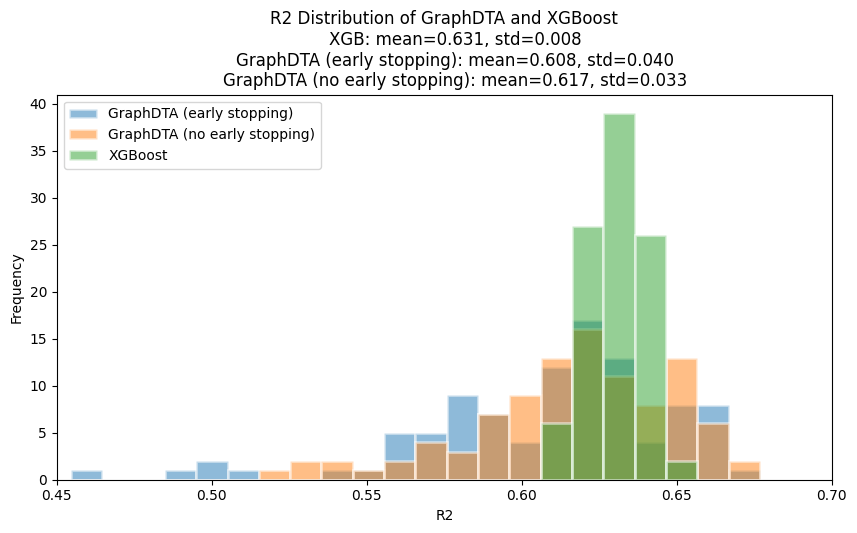

In [25]:
_, ax = plt.subplots(figsize=(10, 5))

df_gdta_early_stopping["r2"].hist(
    bins=np.linspace(0, 1, 100),
    ax=ax,
    label="GraphDTA (early stopping)",
    alpha=0.5,
    linewidth=2,
    edgecolor="white",
    )

df_gdta_no_early_stopping["r2"].hist(
    bins=np.linspace(0, 1, 100),
    ax=ax,
    label="GraphDTA (no early stopping)",
    alpha=0.5,
    linewidth=2,
    edgecolor="white",
    )
df_xgb["test_r2"].hist(
    bins=np.linspace(0, 1, 100),
    ax=ax,
    label="XGBoost",
    alpha=0.5,
    linewidth=2,
    edgecolor="white",
    )
ax.legend()
ax.grid(False)
ax.set_xlim(0.45, 0.7)
ax.set_xlabel("R2")
ax.set_ylabel("Frequency")
ax.set_title(
    f"""R2 Distribution of GraphDTA and XGBoost
    XGB: mean={df_xgb['test_r2'].mean():.3f}, std={df_xgb['test_r2'].std():.3f}
    GraphDTA (early stopping): mean={df_gdta_early_stopping['r2'].mean():.3f}, std={df_gdta_early_stopping['r2'].std():.3f}
    GraphDTA (no early stopping): mean={df_gdta_no_early_stopping['r2'].mean():.3f}, std={df_gdta_no_early_stopping['r2'].std():.3f}"""
    )
ax.legend()
